Import the basic libs

In [1]:
import pandas as pd
import numpy as np

Import the dataset

In [2]:
df = pd.read_csv('Dataset/spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Data Cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [4]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)
df.rename(columns={'v1': 'target', 'v2': 'input'}, inplace=True)
df.head()

,target,input
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [6]:
df['target'] = le.fit_transform(df['target'])
df.head()

,target,input
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.duplicated().sum()

np.int64(403)

In [8]:
df.drop_duplicates(keep='first', inplace=True)
df.duplicated().sum()

np.int64(0)

In [9]:
df.shape

(5169, 2)

## EDA

In [10]:
import matplotlib.pyplot as plt

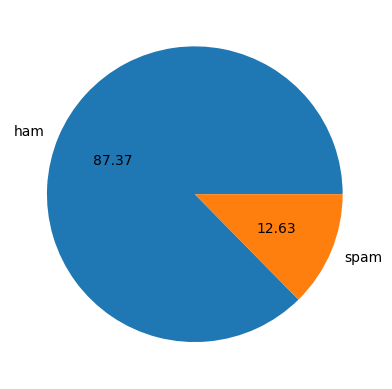

In [11]:
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")
plt.show()

In [12]:
df['num_characters'] = df['input'].apply(len)

In [13]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\madhu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\madhu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\madhu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
df['num_words'] = df['input'].apply(lambda x : len(nltk.word_tokenize(x)))

In [15]:
df['num_sentences'] = df['input'].apply(lambda x : len(nltk.sent_tokenize(x)))

In [16]:
df.head()

,target,input,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [17]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [18]:
df[df['target'] == 0] [['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [19]:
df[df['target'] == 1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [20]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

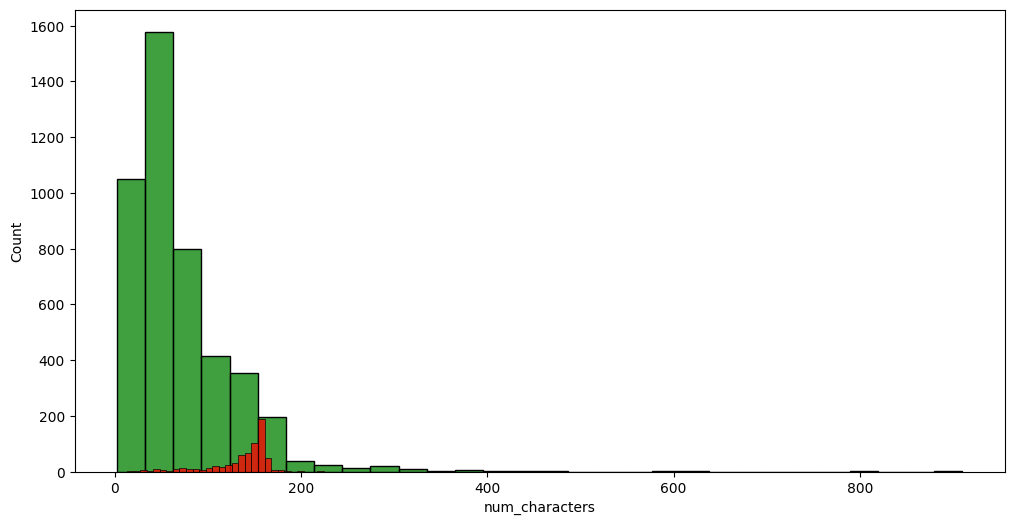

In [21]:
plt.figure(figsize=(12, 6))
sns.histplot(df[df['target'] == 0]['num_characters'], color='green', label='Ham', bins=30)
sns.histplot(df[df['target'] == 1]['num_characters'], color='red', label='Spam', bins=30)

<Axes: >

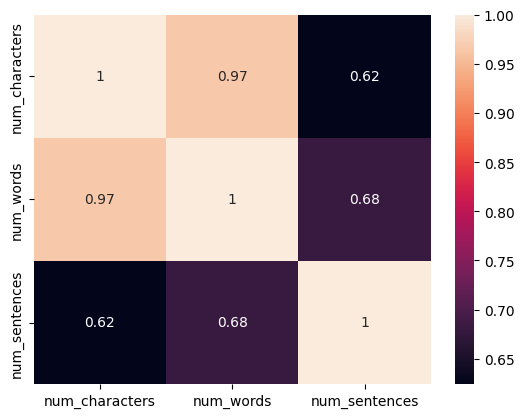

In [22]:
num_df = df[['num_characters', 'num_words', 'num_sentences']]
sns.heatmap(num_df.corr(), annot=True)

## Data preprocessing

In [23]:
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

In [24]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    res = []
    
    for x in text:
        if x.isalnum():
            res.append(x)

    text = res[:]
    res.clear()

    for x in text:
        if x not in stopwords.words('english') and x not in string.punctuation:
            res.append(x)
    
    text = res[:]
    res.clear()

    for x in text:
        res.append(PorterStemmer().stem(x))

    return " ".join(res)

In [25]:
df['transformed_text'] = df['input'].apply(transform_text)

In [26]:
df.head()

,target,input,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [27]:
from wordcloud import WordCloud

In [28]:
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

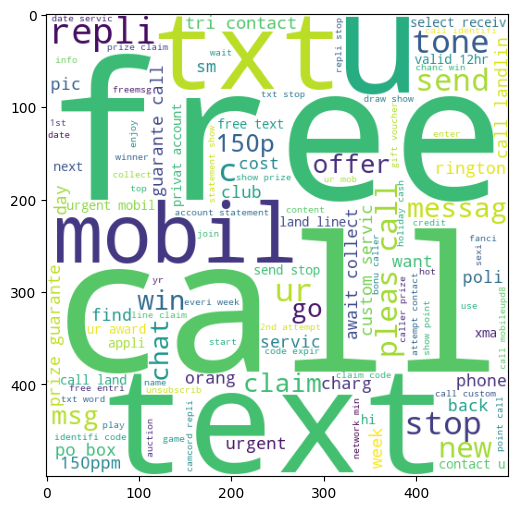

In [29]:
plt.figure(figsize=(12, 6))
plt.imshow(spam_wc)

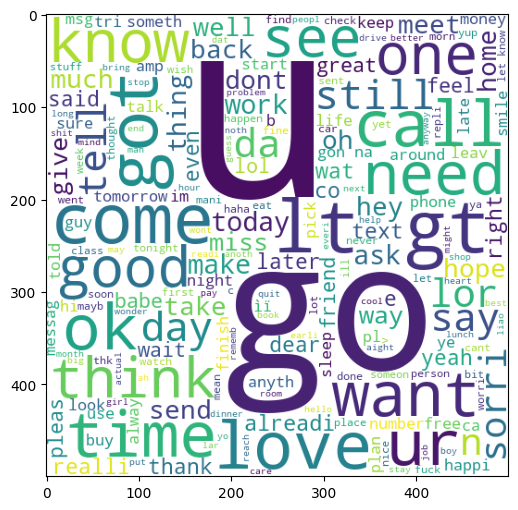

In [30]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(12, 6))
plt.imshow(ham_wc)

## Model Building

In [31]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB

In [32]:
mnb = MultinomialNB()
gnb = GaussianNB()
bnb = BernoulliNB()

In [58]:
tfid = TfidfVectorizer(max_features=3000)
X = tfid.fit_transform(df['transformed_text']).toarray()

In [59]:
x_train, x_test, y_train, y_test = train_test_split(X, df['target'], test_size=0.2, random_state=2)

In [60]:
mnb.fit(x_train, y_train)
gnb.fit(x_train, y_train)
bnb.fit(x_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [61]:
pred_mnb = mnb.predict(x_test)
pred_gnb = gnb.predict(x_test)
pred_bnb = bnb.predict(x_test)

In [62]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score

In [63]:
print("MultinomialNB")
print(confusion_matrix(y_test, pred_mnb))
print(accuracy_score(y_test, pred_mnb))
print(precision_score(y_test, pred_mnb))

MultinomialNB
[[896   0]
 [ 30 108]]
0.9709864603481625
1.0


In [64]:
print("GaussianNB")
print(confusion_matrix(y_test, pred_gnb))
print(accuracy_score(y_test, pred_gnb))
print(precision_score(y_test, pred_gnb))

GaussianNB
[[790 106]
 [ 24 114]]
0.874274661508704
0.5181818181818182


In [65]:
print("BernoulliNB")
print(confusion_matrix(y_test, pred_bnb))
print(accuracy_score(y_test, pred_bnb))
print(precision_score(y_test, pred_bnb))

BernoulliNB
[[895   1]
 [ 16 122]]
0.9835589941972921
0.991869918699187


### Hyperparameter Tunning    

In [66]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [67]:
classifiers_grid = {
    "LogisticRegression" : (LogisticRegression(), {'C': [0.1, 1, 10]}),
    "DecisionTreeClassifier" : (DecisionTreeClassifier(), {'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, 7]}),
    "NaiveBayes" : (MultinomialNB(), {'alpha': [0.1, 0.5, 1.0]}),
    "RandomForestClassifier" : (RandomForestClassifier(), {'criterion': ['gini', 'entropy'], 'n_estimators': [10, 50, 100]}),
    "GradientBoostingClassifier" : (GradientBoostingClassifier(), {'loss': ['log_loss', 'exponential'], 'n_estimators': [10, 50, 100]}),
    "AdaBoostClassifier" : (AdaBoostClassifier(), {'n_estimators': [10, 50, 100]}),
    "BaggingClassifier" : (BaggingClassifier(), {'estimator': [DecisionTreeClassifier(max_depth=3), DecisionTreeClassifier(max_depth=5)], 'n_estimators': [10, 50, 100]}),
    "ExtraTreesClassifier" : (ExtraTreesClassifier(), {'n_estimators': [10, 50, 100]}),
    "SVC" : (SVC(), {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}),
    "KNeighborsClassifier" : (KNeighborsClassifier(), {'n_neighbors': [3, 5, 7]}),
    "XGBClassifier" : (XGBClassifier(), {'n_estimators': [10, 50, 100]})
}

In [68]:
scores = {}
for name, (classifier, params) in classifiers_grid.items():
    grid = GridSearchCV(classifier, params, cv=5, n_jobs=-1)
    grid.fit(x_train, y_train)

    best_estimator = grid.best_estimator_
    pred = best_estimator.predict(x_test)
    
    scores[name] = {
        'best score': grid.best_score_, 
        'best params': grid.best_params_, 
        'best estimator': best_estimator,
        'accuracy': accuracy_score(y_test, pred),
        'precision_score': precision_score(y_test, pred)
    }
        
    

In [70]:
res = pd.DataFrame(scores).T.sort_values(by='precision_score', ascending=False)
res

,best score,best params,best estimator,accuracy,precision_score
KNeighborsClassifier,0.918742,{'n_neighbors': 3},KNeighborsClassifier(n_neighbors=3),0.916828,1.0
RandomForestClassifier,0.971947,"{'criterion': 'gini', 'n_estimators': 50}","(DecisionTreeClassifier(max_features='sqrt', r...",0.977756,0.983193
ExtraTreesClassifier,0.974607,{'n_estimators': 100},"(ExtraTreeClassifier(random_state=1348230910),...",0.977756,0.983193
SVC,0.974849,"{'C': 1, 'kernel': 'linear'}","SVC(C=1, kernel='linear')",0.978723,0.97541
NaiveBayes,0.980895,{'alpha': 0.1},MultinomialNB(alpha=0.1),0.980658,0.968254
LogisticRegression,0.973156,{'C': 10},LogisticRegression(C=10),0.971954,0.965812
XGBClassifier,0.96445,{'n_estimators': 50},"XGBClassifier(base_score=None, booster=None, c...",0.968085,0.948718
GradientBoostingClassifier,0.962273,"{'loss': 'log_loss', 'n_estimators': 100}",([DecisionTreeRegressor(criterion='friedman_ms...,0.959381,0.944444
AdaBoostClassifier,0.931318,{'n_estimators': 100},"(DecisionTreeClassifier(max_depth=1, random_st...",0.931335,0.852632
DecisionTreeClassifier,0.949456,"{'criterion': 'gini', 'max_depth': 7}",DecisionTreeClassifier(max_depth=7),0.94294,0.843478


From the above dataframe we come to know that the best overall model is multinominalnb, but the precision is high for knn and randomforest we are going with the naice bayes multinominalnb model.

In [75]:
model = scores['NaiveBayes']['best estimator']

In [76]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('tfid.pkl', 'wb') as f:
    pickle.dump(tfid, f)